In [4]:
import sqlite3
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

# Define the message types we expect
TOPIC_TYPES = {
    '/imu': 'sensor_msgs/msg/Imu',
    '/vio/odom': 'nav_msgs/msg/Odometry',
    '/ground_truth/odom': 'nav_msgs/msg/Odometry',
}

def analyze_bag(bag_path):
    # Connect to the SQLite3 database (.db3 file)
    try:
        conn = sqlite3.connect(bag_path)
        cursor = conn.cursor()
    except Exception as e:
        print(f"Error opening bag: {e}")
        return

    # Get topic IDs
    topics = {}
    for row in cursor.execute("SELECT id, name, type FROM topics"):
        topics[row[0]] = {'name': row[1], 'type': row[2]}

    # Data containers
    imu_acc_z = []
    vio_path = {'x': [], 'y': []}
    gt_path = {'x': [], 'y': []}
    timestamps = []

    print(f"Reading bag: {bag_path}...")
    print("topics found:")
    for topic_id, info in topics.items():
        print(f"  ID {topic_id}: {info['name']} ({info['type']})")

    # Read messages
    for row in cursor.execute("SELECT topic_id, timestamp, data FROM messages"):
        topic_id = row[0]
        timestamp = row[1]
        data = row[2]

        topic_name = topics[topic_id]['name']
        topic_type = topics[topic_id]['type']

        # Instantiate the message class
        msg_class = get_message(topic_type)
        msg = deserialize_message(data, msg_class)

        if topic_name == '/imu':
            # Check standard gravity (approx 9.8 or -9.8)
            imu_acc_z.append(msg.linear_acceleration.z)

        elif topic_name == '/vio/odom':
            vio_path['x'].append(msg.pose.pose.position.x)
            vio_path['y'].append(msg.pose.pose.position.y)

        elif topic_name == '/ground_truth/odom':
            gt_path['x'].append(msg.pose.pose.position.x)
            gt_path['y'].append(msg.pose.pose.position.y)

    conn.close()

    # --- ANALYSIS ---
    print("\n=== ANALYSIS REPORT ===")

    # 1. IMU Gravity Check
    if imu_acc_z:
        avg_z = np.mean(imu_acc_z)
        print(f"[IMU] Average Z-Accel: {avg_z:.4f} m/s^2")
        if 9.0 < abs(avg_z) < 10.5:
            print("      -> PASSED: Gravity looks normal (near 9.8).")
        else:
            print("      -> FAILED: Gravity is weird! Check IMU orientation in URDF.")
    else:
        print("[IMU] No IMU data found!")

    # 2. Trajectory Plotting
    plt.figure(figsize=(10, 6))
    if gt_path['x']:
        plt.plot(gt_path['x'], gt_path['y'], 'g-', label='Ground Truth', linewidth=2)
    if vio_path['x']:
        plt.plot(vio_path['x'], vio_path['y'], 'r--', label='VIO Estimate', linewidth=1)

    plt.title("Sanity Check: Ground Truth vs VIO")
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.legend()
    plt.grid(True)
    plt.axis('equal')

    print("\nOpening plot window...")
    plt.show()


Reading bag: /workspaces/585_Probabilistic_Robotics/sanity_check/sanity_check_0.db3...
topics found:
  ID 1: /vio/odom (nav_msgs/msg/Odometry)
  ID 2: /tf_static (tf2_msgs/msg/TFMessage)
  ID 3: /tf (tf2_msgs/msg/TFMessage)
  ID 4: /imu (sensor_msgs/msg/Imu)

=== ANALYSIS REPORT ===
[IMU] Average Z-Accel: 9.7996 m/s^2
      -> PASSED: Gravity looks normal (near 9.8).

Opening plot window...


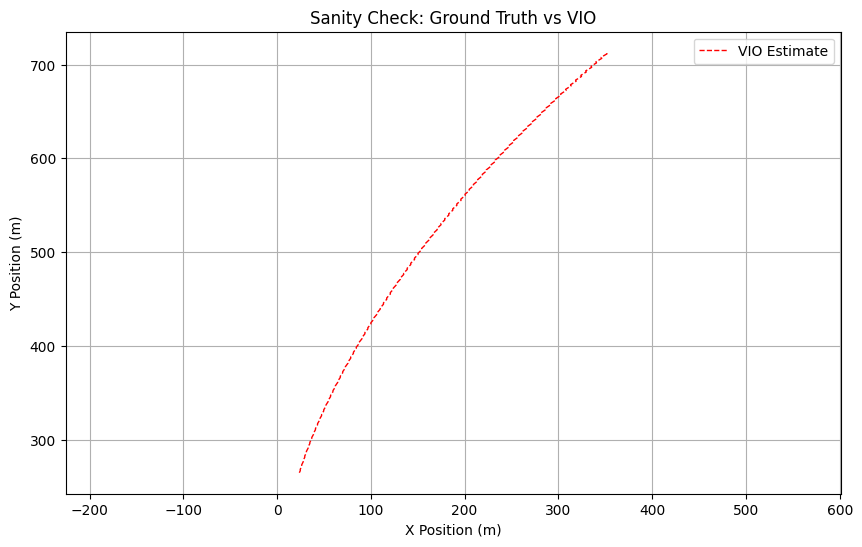

In [5]:
bag_path = "/workspaces/585_Probabilistic_Robotics/sanity_check/sanity_check_0.db3"
analyze_bag(bag_path)